In [ ]:
import pandas as pd
import mysql.connector
import os

# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('geolocation.csv', 'geolocation'),
    ('order_items.csv', 'order_items'),
    ('orders.csv', 'orders'),
    ('products.csv', 'products'),
    ('payments.csv', 'payments') ,
    ('sellers.csv', 'selllers') 
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='YOUR_PASSWORD',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = "data"

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()

Processing customers.csv
NaN values before replacement:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Processing geolocation.csv
NaN values before replacement:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

Processing order_items.csv
NaN values before replacement:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Processing orders.csv
NaN values before replacement:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered

In [1]:
import mysql.connector

db = mysql.connector.connect(
    host='localhost',
    user='root',
    password='callofduty',
    database='ecommerce'
)
cur = db.cursor()

# list only unique cities where customers located

In [ ]:
query = "select distinct customer_city from customers;"
cur.execute(query)
pd.DataFrame(cur.fetchall()).head(5)

,0
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


# total orders in 2017


In [ ]:
query2 = "select count(order_id) from orders where year(order_purchase_timestamp) = 2017;"
cur.execute(query2)
cur.fetchall()

[(135303,)]

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# total sales per product category


In [ ]:
query3= """select upper(products.product_category)category,
        round(sum(payments.payment_value),2) sales
        from products join order_items
        on products.product_id = order_items.product_id
        join payments
        on payments.order_id = order_items.order_id
        group by category """

cur.execute(query3)
pd.DataFrame(cur.fetchall(), columns= ("category", "sales")).head(4)

,category,sales
0,PERFUMERY,13681943.82
1,FURNITURE DECORATION,38614762.58
2,TELEPHONY,13145815.37
3,BED TABLE BATH,46238949.12


# calculate the percentage of orders that paid in installments


In [ ]:
query4 = """ select (sum(case when payment_installments >=1 then 1 
            else 0 end))/ count(*)*100 from payments"""

cur.execute(query4)
cur.fetchall()[0][0]


Decimal('99.9981')

# count the customers from each state


In [ ]:

query5 = "select customer_state,  count(customer_id) from customers group by customer_state;"

cur.execute(query5)
df_customer_count_per_state = pd.DataFrame(cur.fetchall(), columns= ("customer_state", "total_customers"))
df_customer_count_per_state
sorted_df_customer_count_per_state = df_customer_count_per_state.sort_values(by= "total_customers", ascending= False)
sorted_df_customer_count_per_state.head(5)

,customer_state,total_customers
0,SP,166984
4,RJ,51408
2,MG,46540
5,RS,21864
3,PR,20180


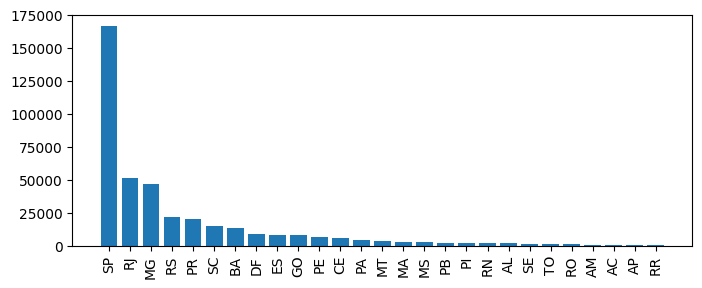

In [44]:
plt.figure(figsize= (8,3))
plt.bar(sorted_df_customer_count_per_state["customer_state"], sorted_df_customer_count_per_state["total_customers"])
plt.xticks(rotation = 90)
plt.show()


# calculate the number of orders per month in 2018 

In [41]:
query6 = """select monthname(order_purchase_timestamp), count(order_id) as order_count from orders where year (order_purchase_timestamp) = 2018 
group by monthname(order_purchase_timestamp);"""

cur.execute(query6)
df_order_count_per_month_2018 = pd.DataFrame(cur.fetchall(), columns= ("months_2018", "order_count"))
df_order_count_per_month_2018
sorted_df_order_count_per_month_2018 = df_order_count_per_month_2018.sort_values(by= "order_count", ascending= False)
sorted_df_order_count_per_month_2018.head(5)

,months_2018,order_count
5,January,21807
4,March,21633
7,April,20817
6,May,20619
2,February,20184


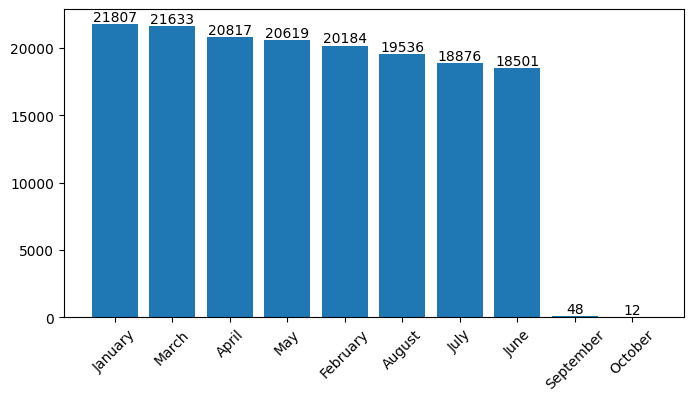

In [ ]:
plt.figure(figsize= (8,4))
bars = plt.bar(sorted_df_order_count_per_month_2018["months_2018"], sorted_df_order_count_per_month_2018["order_count"])
plt.xticks(rotation = 45)
plt.gca().bar_label(bars)  
plt.show()

# Average number of products per order based on per city

In [7]:
query7 = """ with product_per_order as (
select orders.order_id as ordr , customers.customer_city as city , count(order_items.product_id) as product_count
from orders join order_items on orders.order_id = order_items.order_id
            join customers on orders.customer_id = customers.customer_id
            group by ordr, city
            ) 
select city , ordr, avg(product_count) from product_per_order group by city, ordr ; """

cur.execute(query7)
pd.DataFrame(cur.fetchall(), columns=("city","ordr" ,"avg_product_count")).sort_values(by= "avg_product_count", ascending= False).head(4)


,city,ordr,avg_product_count
46034,sao paulo,8272b63d03f5f79c56e9e4120aec44ef,756.0000
70217,sao paulo,1b15974a0141d54e36626dca3fdc731a,720.0000
5117,goiania,ab14fdcfbe524636d65ee38360e22ce8,720.0000
68545,uniao da vitoria,428a2f660dc84138d969ccd69a0ab6d5,540.0000


# calculate the percentage of total revenue contributed by each product category

In [24]:
query8 = """select products.product_category, round((sum(payments.payment_value)/( select sum(payment_value) from payments))*100,1) as category_revenue from products 
		join order_items on products.product_id = order_items.product_id
        join payments on order_items.order_id = payments.order_id
		group by products.product_category order by category_revenue desc;"""

cur.execute(query8)
df_category_revenue = pd.DataFrame(cur.fetchall(), columns= ("product_category", "category_revenue"))
df_category_revenue.head(5)
df_category_revenue["product_category"] = df_category_revenue["product_category"].fillna("Unknown")
df_category_revenue["category_revenue"] = df_category_revenue["category_revenue"].fillna(0)
df_category_revenue.head(5)

,product_category,category_revenue
0,bed table bath,96.3
1,HEALTH BEAUTY,93.2
2,computer accessories,89.1
3,Furniture Decoration,80.4
4,Watches present,80.3


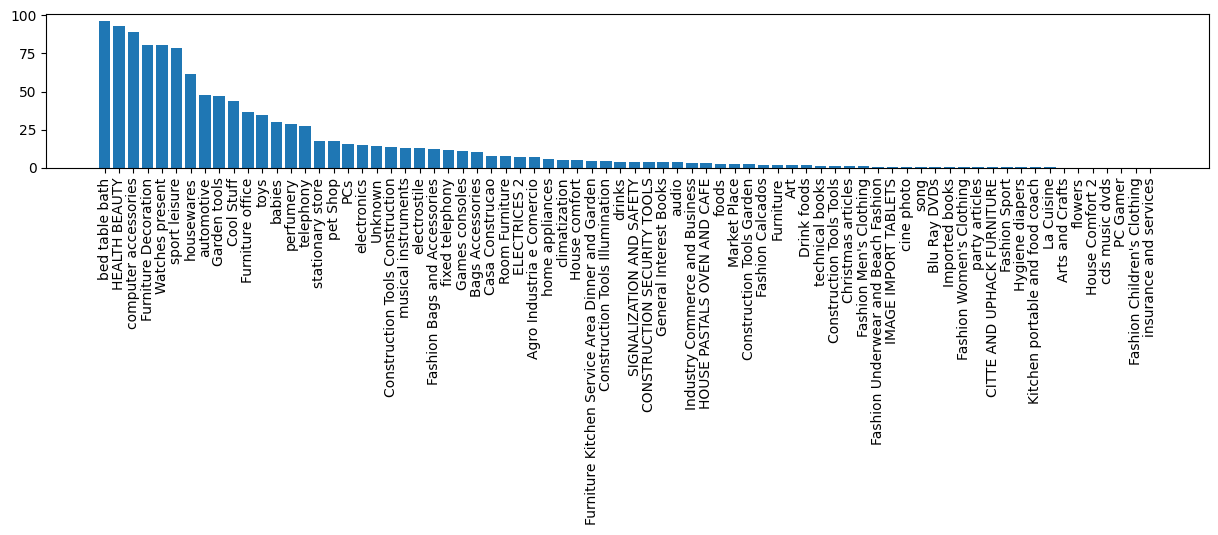

In [28]:
plt.figure(figsize= (15,2))
plt.bar(df_category_revenue["product_category"], df_category_revenue ["category_revenue"])
plt.xticks(rotation = 90)

plt.show()



# The correlation between product price and how many times a product has been purchased

In [11]:
query9 = """select product_id, price, max(order_item_id) from order_items
group by product_id, price order by max(order_item_id)  desc;
"""

cur.execute(query9)
df_product_purchase_count = pd.DataFrame(cur.fetchall(), columns=("product id", "price", "purchase_count"))
df_product_purchase_count.head(5)


,product id,price,purchase_count
0,79ce45dbc2ea29b22b5a261bbb7b7ee7,7.8,21
1,270516a3f41dc035aa87d220228f844c,1.2,20
2,9571759451b1d780ee7c15012ea109d4,98.7,20
3,ee3d532c8a438679776d222e997606b3,100.0,20
4,37eb69aca8718e843d897aa7b82f462d,51.0,15


In [18]:
df_product_purchase_count[["purchase_count","price"]].corr()

,purchase_count,price
purchase_count,1.000000,-0.088116
price,-0.088116,1.000000


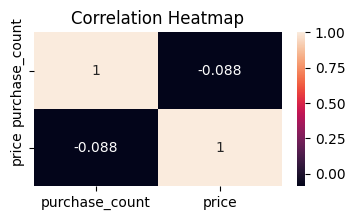

In [27]:
plt.figure(figsize = (4,2))
sns.heatmap(df_product_purchase_count[["purchase_count","price"]].corr(), annot=True)
plt.title("Correlation Heatmap")

plt.show()


# calculate revenue per seller

In [30]:
query10 =  """select seller_id as seller , sum(price) as revenue from order_items
        group by seller_id  order by revenue desc ;"""

cur.execute(query10)
pd.DataFrame(cur.fetchall(), columns= ("seller", "revenue")).head(5)


,seller,revenue
0,4869f7a5dfa277a7dca6462dcf3b52b2,688417.885048
1,53243585a1d6dc2643021fd1853d8905,668328.148636
2,4a3ca9315b744ce9f8e9374361493884,601418.764378
3,fa1c13f2614d7b5c4749cbc52fecda94,582126.088188
4,7c67e1448b00f6e969d365cea6b010ab,563771.675817


# calculate moving average of order values per customer over their order history



In [3]:
query11 = """select customer_id ,order_purchase_timestamp,  payment_value , avg(payment_value) over (partition by customer_id  order by order_purchase_timestamp
 rows between 2 preceding and current row) as moving_avg 
 from (select orders.customer_id , orders.order_purchase_timestamp , payments.payment_value from orders 
        join payments on orders.order_id = payments.order_id) as a ;"""

cur.execute(query11)
pd.DataFrame(cur.fetchall(), columns= ("customer", "order time","payment", "moving avg")).head(10)

,customer,order time,payment,moving avg
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
2,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
3,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
4,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
5,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
6,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
7,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
8,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
9,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004


# calculate the cumalative sales per month of each year

In [10]:
query12= """select years, months, month_name, sales , SUM(sales) over (order by years, months) as running_total_sale
from (select round(sum(payments.payment_value),2) as sales,
		     year(orders.order_purchase_timestamp) as years ,
             month(orders.order_purchase_timestamp) as months , 
             monthname(orders.order_purchase_timestamp) as month_name from orders 
      join payments on orders.order_id  = payments.order_id 
      group  by years, months, month_name order by years, months ) as a ;"""


cur.execute(query12)
df_cumulative_sale_by_month = pd.DataFrame(cur.fetchall(), columns = ("years", "months", "month_name","sales", "running_total_sale"))
df_cumulative_sale_by_month.head(10)


,years,months,month_name,sales,running_total_sale
0,2016,9,September,2270.16,2270.16
1,2016,10,October,531814.32,534084.48
2,2016,12,December,176.58,534261.06
3,2017,1,January,1246392.36,1780653.42
4,2017,2,February,2627172.09,4407825.51
5,2017,3,March,4048772.40,8456597.91
6,2017,4,April,3760092.27,12216690.18
7,2017,5,May,5336269.38,17552959.56
8,2017,6,June,4601487.42,22154446.98
9,2017,7,July,5331446.28,27485893.26


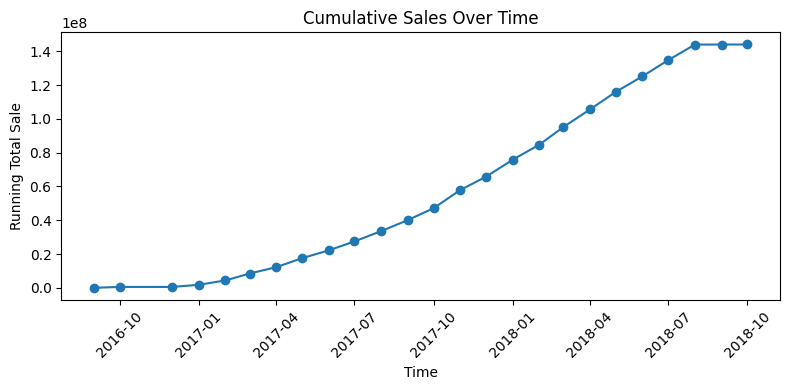

In [14]:
# create proper date column
df_cumulative_sale_by_month['date'] = pd.to_datetime(
    df_cumulative_sale_by_month[['years', 'months']].assign(day=1)
)

plt.figure(figsize=(8,4))

plt.plot(
    df_cumulative_sale_by_month['date'],
    df_cumulative_sale_by_month['running_total_sale'],
    marker='o'
)

plt.xlabel("Time")
plt.ylabel("Running Total Sale")
plt.title("Cumulative Sales Over Time")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# calculate the year over year growth rate of total sales

In [10]:
query13= """with b as (select years, sales , lag(sales , 1) over (order by years) as previous_year_sales
from(select year(orders.order_purchase_timestamp) as years, round(sum(payments.payment_value),2) as sales from orders
        join payments on orders.order_id =  payments.order_id
        group by years order by years) as a) 
        
select years, sales, previous_year_sales, round((((sales - previous_year_sales)/previous_year_sales )*100),2) as YOY_GROWTH from b;"""

cur.execute(query13)
df_yoy_growth = pd.DataFrame(cur.fetchall() ,columns = ("years", "sales", "pre_year_sales", "yoy_growth")).fillna(0)
df_yoy_growth

,years,sales,pre_year_sales,yoy_growth
0,2016,534261.06,0.00,0.0
1,2017,65247720.55,534261.06,12112.7
2,2018,78297867.47,65247720.55,20.0


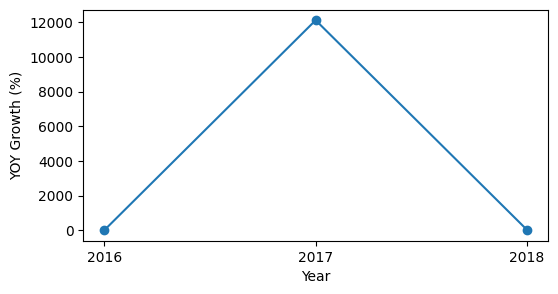

In [11]:
plt.figure(figsize=(6,3))

plt.plot(
    df_yoy_growth["years"], 
    df_yoy_growth["yoy_growth"],
    marker='o'
)

plt.xticks(df_yoy_growth["years"])   # 👈 important line

plt.xlabel("Year")
plt.ylabel("YOY Growth (%)")

plt.show()

# identifying the top 5 customers who spent most money each year

In [12]:
query14 = """with b as (select customer, years, total_spent, dense_rank() over(partition by years order by total_spent desc) as d_rank 
 from(select orders.customer_id as customer , 
		year(orders.order_purchase_timestamp) as years , 
		round(sum(payments.payment_value),2) as total_spent
 from orders join payments on orders.order_id = payments.order_id
			  group by customer, years order by total_spent desc) as a )
              
select customer, years, total_spent, d_rank from b where d_rank <= 3 ;"""

cur.execute(query14)
pd.DataFrame(cur.fetchall())

,0,1,2,3
0,a9dc96b027d1252bbac0a9b72d837fc6,2016,12811.95,1
1,1d34ed25963d5aae4cf3d7f3a4cda173,2016,12606.66,2
2,4a06381959b6670756de02e07b83815f,2016,11050.02,3
3,1617b1357756262bfa56ab541c47bc16,2017,122976.72,1
4,c6e2731c5b391845f6800c97401a43a9,2017,62363.79,2
5,3fd6777bbce08a352fddd04e4a7cc8f6,2017,60539.94,3
6,ec5b2ba62e574342386871631fafd3fc,2018,65473.92,1
7,f48d464a0baaea338cb25f816991ab1f,2018,62299.89,2
8,e0a2412720e9ea4f26c1ac985f6a7358,2018,43284.96,3
